# Bank Marketing Dataset
### Model development and Performance Evaluation

#### By: Jessica, Carmen, Emma, Yanting

## **Business Problem:**
##### The business objective is to identify which custome characteristics are associated with a higher likelihood of subscribing to a term deposit so that marketing efforts can be focused on the most promising prospects.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.tree import plot_tree

In [2]:
# upload file from google colab
from google.colab import files
uploaded = files.upload()

Saving bank_mkt_clean_final.csv to bank_mkt_clean_final.csv


In [3]:
df = pd.read_csv("bank_mkt_clean_final.csv")

df.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,y_yes,poutcome_nonexistent,poutcome_success
0,0.500000,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
1,0.538462,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
2,-0.230769,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
3,-0.115385,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
4,0.500000,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0


In [4]:
df.shape

(36562, 53)

In [5]:
df.columns

Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'marital_married',
       'marital_single', 'marital_unknown', 'default_unknown', 'default_yes',
       'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes',
       'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'y_yes', 'poutcome_nonexistent', 'poutcome_succ

In [6]:
df.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,y_yes,poutcome_nonexistent,poutcome_success
0,0.500000,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
1,0.538462,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
2,-0.230769,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
3,-0.115385,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0
4,0.500000,-1.0,1.0,-1.0,0.875,0.397506,0.205021,0.914759,0.719471,0,...,0,0,0,1,0,0,0,0,1,0


# **Campaign Subscription Outcome**

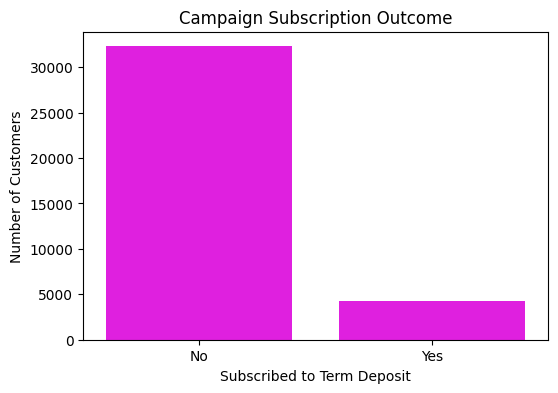

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='y_yes',
    data=df,
    color='magenta'
)

plt.title('Campaign Subscription Outcome')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Number of Customers')

plt.xticks([0,1], ['No','Yes'])

plt.show()

### During this campaign most did not subscribe to the term deposit

# **Independent Samples t-test: Campaign Contacts vs. Subscription Outcome**

In [20]:
from scipy.stats import ttest_ind

no_group = df[df['y_yes'] == 0]['campaign']
yes_group = df[df['y_yes'] == 1]['campaign']

t_stat, p_value = ttest_ind(no_group, yes_group, equal_var=False)

print("Mean campaign contacts - No:", no_group.mean())
print("Mean campaign contacts - Yes:", yes_group.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

Mean campaign contacts - No: -0.558486124876115
Mean campaign contacts - Yes: -0.6441740758072064
t-statistic: 11.117496199625412
p-value: 1.9968039042068163e-28


#### The t-test showed a statistically significant difference in the average number of campaign contacts between customers who subscribed and those who did not subscribe (p < 0.001). This suggests that campaign activity is related to subscription outcomes.

# **Hypothesis Testing: Chi-Squared Test**

In [8]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['housing_yes'], df['y_yes'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square:", chi2)
print("p-value:", p)

Chi-Square: 4.832797582735421
p-value: 0.027923285383957108


In [9]:
if p < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


In [10]:
table = pd.crosstab(df['poutcome_success'], df['y_yes'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square:", chi2)
print("p-value:", p)

Chi-Square: 3583.4148147292713
p-value: 0.0


In [11]:
if p < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


 #### Both tests identified statistically significant relationships with subscription outcomes, with previous campaign success showing the strongest relationship and emerging as one of the most important predictors of customer subscription behavior.

In [12]:
X = df.drop('y_yes', axis=1)

y = df['y_yes']

print(X.shape)
print(y.shape)

(36562, 52)
(36562,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(25593, 52)
(10969, 52)
(25593,)
(10969,)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

In [16]:
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1:", f1_score(y_test, log_pred))

Accuracy: 0.8952502507065366
Precision: 0.7035294117647058
Recall: 0.22617246596066565
F1: 0.34230108757870636


#### Logistic Regression is conservative. It avoids many false positives, but it misses a large number of actual subscribers.

In [18]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1:", f1_score(y_test, tree_pred))

Accuracy: 0.8336220257088157
Precision: 0.32546842470506593
Recall: 0.3547655068078669
F1: 0.3394860658704307


In [ ]:
small_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

small_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

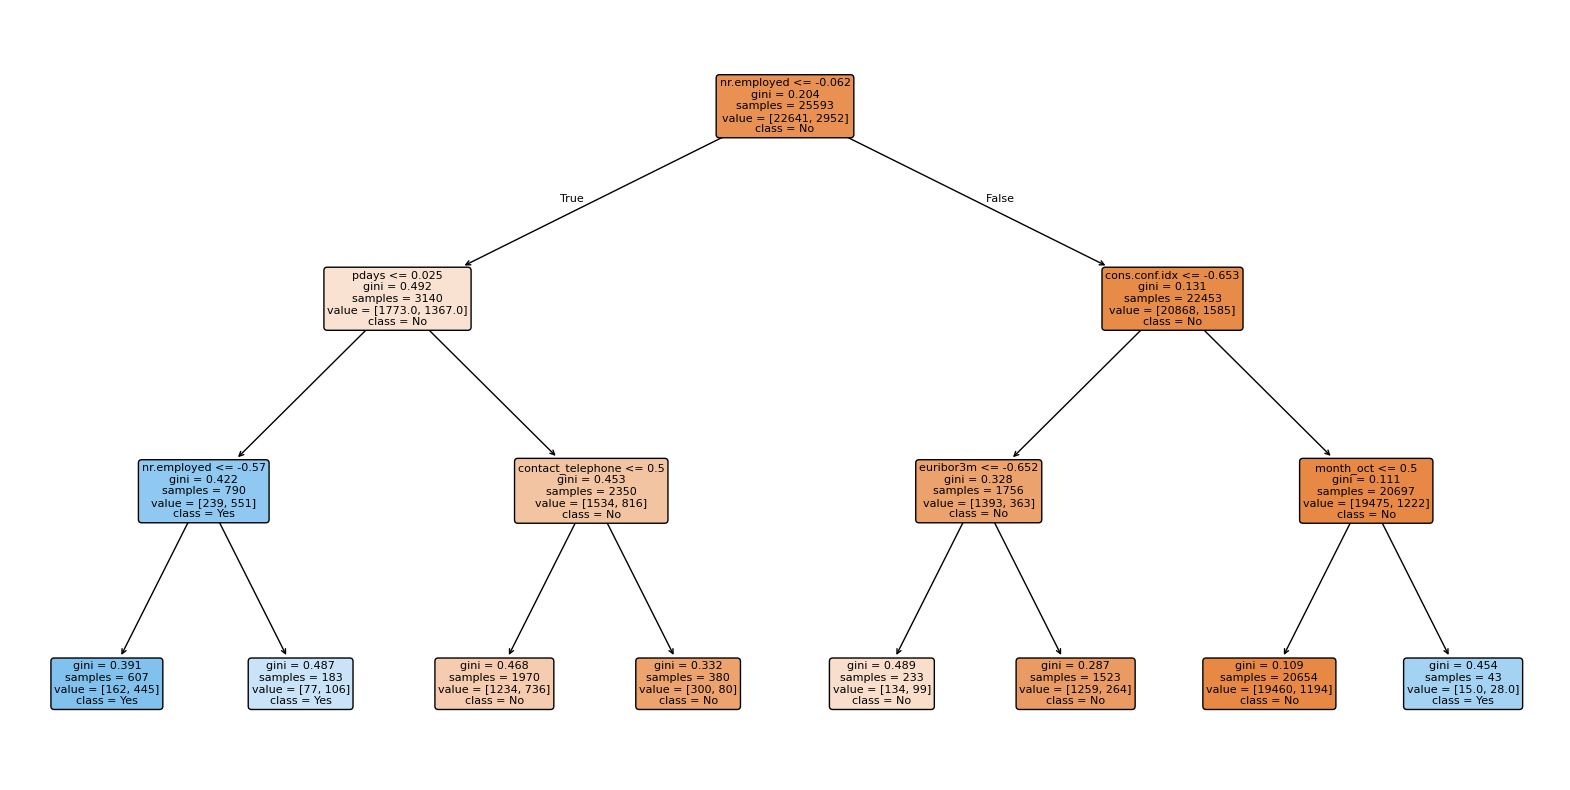

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    small_tree,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

#### The decision tree illustrates how customer characteristics and campaign variables are used to classify subscription outcomes. The top splits represent the most influential decision points, while deeper branches capture more specific customer segments.

#### Better at finding potential subscribers, but produces more false positives.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_pred_original = rf_pred

In [ ]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Accuracy: 0.886589479442064
Precision: 0.5592705167173252
Recall: 0.2783661119515885
F1: 0.3717171717171717


In [ ]:
# The Random Forest model was highly effective at identifying
# customers who were unlikely to subscribe, correctly
# classifying 9,356 non-subscribers. However, the model
# missed a substantial number of actual subscribers
# (954), indicating that while overall accuracy was
# high, there is still room for improvement in
#identifying potential customers for marketing outreach.

In [ ]:
# Best Model:
# Although Logistic Regression achieved slightly higher
# Accuracy, Random Forest produced the highest F1 Score,
# indicating the best balance between identifying
# potential subscribers and minimizing classification errors.

The Random Forest model achieved strong overall classification performance and correctly identified most non-subscribers. However, due to the imbalanced nature of the dataset, the model missed some potential subscribers, resulting in a lower recall rate. Despite this limitation, Random Forest provided the best overall balance between precision and recall among the models tested.

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
0,age,0.173628
7,euribor3m,0.127113
1,campaign,0.076321
2,pdays,0.042545
33,housing_yes,0.039363
8,nr.employed,0.036071
6,cons.conf.idx,0.027963
35,loan_yes,0.025543
51,poutcome_success,0.025521
4,emp.var.rate,0.025072


# **Feature Importance Visual**

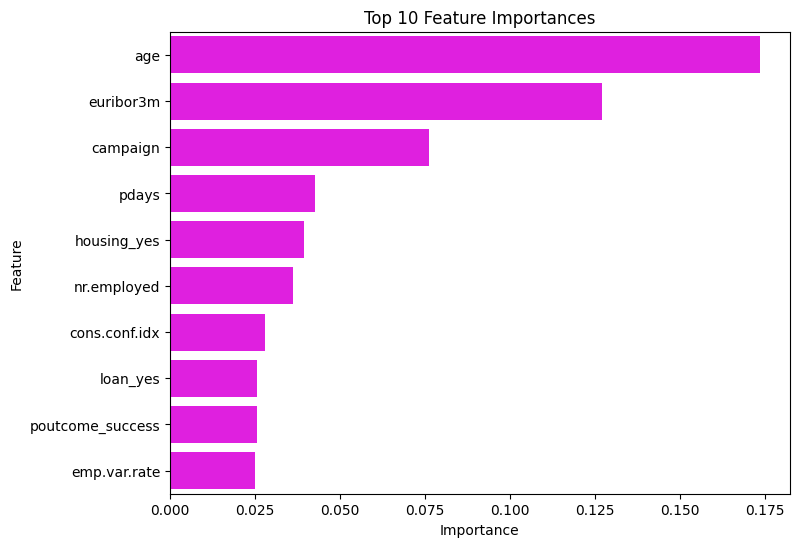

In [ ]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature',
    color='magenta'
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.895, 0.834, 0.886],
    'Precision': [0.704, 0.325, 0.558],
    'Recall': [0.226, 0.354, 0.278],
    'F1': [0.342, 0.339, 0.372]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.895,0.704,0.226,0.342
1,Decision Tree,0.834,0.325,0.354,0.339
2,Random Forest,0.886,0.558,0.278,0.372


# **Feature Section Analysis**

In [ ]:
# ============================================================
# FEATURE SELECTION LOOP
# Tests 1 feature, then 2 features, then 3 features, etc.
# Uses features ordered by Random Forest importance
# ============================================================

feature_order = importance['Feature'].tolist()

loop_results = []

for i in range(1, len(feature_order) + 1):

    selected_features = feature_order[:i]

    X_train_sub = X_train[selected_features]
    X_test_sub = X_test[selected_features]

    # -------------------------
    # Logistic Regression
    # -------------------------
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_sub)

    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train_scaled, y_train)

    log_pred = log_model.predict(X_test_scaled)

    loop_results.append({
        'Number of Features': i,
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, log_pred),
        'Precision': precision_score(y_test, log_pred),
        'Recall': recall_score(y_test, log_pred),
        'F1 Score': f1_score(y_test, log_pred),
        'Features Used': selected_features
    })

    # -------------------------
    # Decision Tree
    # -------------------------
    tree_model = DecisionTreeClassifier(random_state=42)
    tree_model.fit(X_train_sub, y_train)

    tree_pred = tree_model.predict(X_test_sub)

    loop_results.append({
        'Number of Features': i,
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test, tree_pred),
        'Precision': precision_score(y_test, tree_pred),
        'Recall': recall_score(y_test, tree_pred),
        'F1 Score': f1_score(y_test, tree_pred),
        'Features Used': selected_features
    })

    # -------------------------
    # Random Forest
    # -------------------------
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_model.fit(X_train_sub, y_train)

    rf_pred = rf_model.predict(X_test_sub)

    loop_results.append({
        'Number of Features': i,
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred),
        'Recall': recall_score(y_test, rf_pred),
        'F1 Score': f1_score(y_test, rf_pred),
        'Features Used': selected_features
    })

# Convert results to DataFrame
loop_results_table = pd.DataFrame(loop_results)

loop_results_table

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Number of Features,Model,Accuracy,Precision,Recall,F1 Score,Features Used
0,1,Logistic Regression,0.879479,0.000000,0.000000,0.000000,[age]
1,1,Decision Tree,0.878840,0.360000,0.006808,0.013363,[age]
2,1,Random Forest,0.878840,0.360000,0.006808,0.013363,[age]
3,2,Logistic Regression,0.879479,0.000000,0.000000,0.000000,"[age, euribor3m]"
4,2,Decision Tree,0.878658,0.492537,0.224660,0.308571,"[age, euribor3m]"
...,...,...,...,...,...,...,...
151,51,Decision Tree,0.834169,0.326345,0.353253,0.339266,"[age, euribor3m, campaign, pdays, housing_yes,..."
152,51,Random Forest,0.888322,0.574730,0.282148,0.378488,"[age, euribor3m, campaign, pdays, housing_yes,..."
153,52,Logistic Regression,0.895250,0.703529,0.226172,0.342301,"[age, euribor3m, campaign, pdays, housing_yes,..."
154,52,Decision Tree,0.832163,0.317382,0.341150,0.328837,"[age, euribor3m, campaign, pdays, housing_yes,..."


In [ ]:
loop_results_table.sort_values(by='F1 Score', ascending=False).head(10)

,Number of Features,Model,Accuracy,Precision,Recall,F1 Score,Features Used
128,43,Random Forest,0.888869,0.578387,0.287443,0.384032,"[age, euribor3m, campaign, pdays, housing_yes,..."
152,51,Random Forest,0.888322,0.574730,0.282148,0.378488,"[age, euribor3m, campaign, pdays, housing_yes,..."
98,33,Random Forest,0.887957,0.570992,0.282905,0.378351,"[age, euribor3m, campaign, pdays, housing_yes,..."
71,24,Random Forest,0.885040,0.543262,0.289713,0.377898,"[age, euribor3m, campaign, pdays, housing_yes,..."
20,7,Random Forest,0.876744,0.482353,0.310136,0.377532,"[age, euribor3m, campaign, pdays, housing_yes,..."
86,29,Random Forest,0.887410,0.565809,0.282905,0.377206,"[age, euribor3m, campaign, pdays, housing_yes,..."
146,49,Random Forest,0.887319,0.564955,0.282905,0.377016,"[age, euribor3m, campaign, pdays, housing_yes,..."
68,23,Random Forest,0.884857,0.541844,0.288956,0.376912,"[age, euribor3m, campaign, pdays, housing_yes,..."
149,50,Random Forest,0.886954,0.561377,0.283661,0.376884,"[age, euribor3m, campaign, pdays, housing_yes,..."
155,52,Random Forest,0.887136,0.563444,0.282148,0.376008,"[age, euribor3m, campaign, pdays, housing_yes,..."


In [ ]:
peak_table = loop_results_table.pivot(
    index='Number of Features',
    columns='Model',
    values='F1 Score'
)

peak_table

Model,Decision Tree,Logistic Regression,Random Forest
Number of Features,,,
1,0.013363,0.000000,0.013363
2,0.308571,0.000000,0.331307
3,0.308349,0.000000,0.318713
4,0.333644,0.315729,0.361549
5,0.332885,0.315729,0.350261
6,0.359109,0.292216,0.373901
7,0.344227,0.295102,0.377532
8,0.334040,0.295102,0.362219
9,0.334742,0.292917,0.364809


Number of Features                                                   43
Model                                                     Random Forest
Accuracy                                                       0.888869
Precision                                                      0.578387
Recall                                                         0.287443
F1 Score                                                       0.384032
Features Used         [age, euribor3m, campaign, pdays, housing_yes,...
Name: 128, dtype: object


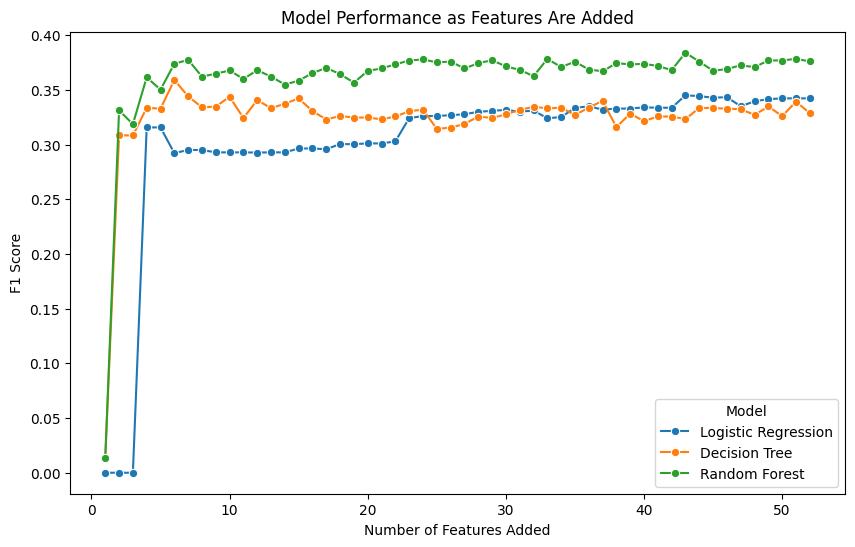

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=loop_results_table,
    x='Number of Features',
    y='F1 Score',
    hue='Model',
    marker='o'
)

plt.title('Model Performance as Features Are Added')
plt.xlabel('Number of Features Added')
plt.ylabel('F1 Score')

plt.show()

In [ ]:
feature_order = importance['Feature'].tolist()

In [ ]:
loop_results_table.sort_values(
    by='F1 Score',
    ascending=False
).head(10)

,Number of Features,Model,Accuracy,Precision,Recall,F1 Score,Features Used
128,43,Random Forest,0.888869,0.578387,0.287443,0.384032,"[age, euribor3m, campaign, pdays, housing_yes,..."
152,51,Random Forest,0.888322,0.574730,0.282148,0.378488,"[age, euribor3m, campaign, pdays, housing_yes,..."
98,33,Random Forest,0.887957,0.570992,0.282905,0.378351,"[age, euribor3m, campaign, pdays, housing_yes,..."
71,24,Random Forest,0.885040,0.543262,0.289713,0.377898,"[age, euribor3m, campaign, pdays, housing_yes,..."
20,7,Random Forest,0.876744,0.482353,0.310136,0.377532,"[age, euribor3m, campaign, pdays, housing_yes,..."
86,29,Random Forest,0.887410,0.565809,0.282905,0.377206,"[age, euribor3m, campaign, pdays, housing_yes,..."
146,49,Random Forest,0.887319,0.564955,0.282905,0.377016,"[age, euribor3m, campaign, pdays, housing_yes,..."
68,23,Random Forest,0.884857,0.541844,0.288956,0.376912,"[age, euribor3m, campaign, pdays, housing_yes,..."
149,50,Random Forest,0.886954,0.561377,0.283661,0.376884,"[age, euribor3m, campaign, pdays, housing_yes,..."
155,52,Random Forest,0.887136,0.563444,0.282148,0.376008,"[age, euribor3m, campaign, pdays, housing_yes,..."


In [ ]:
best_row = loop_results_table.loc[
    loop_results_table['F1 Score'].idxmax()
]

print(best_row)

Number of Features                                                   43
Model                                                     Random Forest
Accuracy                                                       0.888869
Precision                                                      0.578387
Recall                                                         0.287443
F1 Score                                                       0.384032
Features Used         [age, euribor3m, campaign, pdays, housing_yes,...
Name: 128, dtype: object


In [ ]:
len(X.columns)

52

#### The Random Forest reached its maximum F1 score at 43 features. Additional features did not improve Performance and resulted in a slight decline, indicating diminishing returns

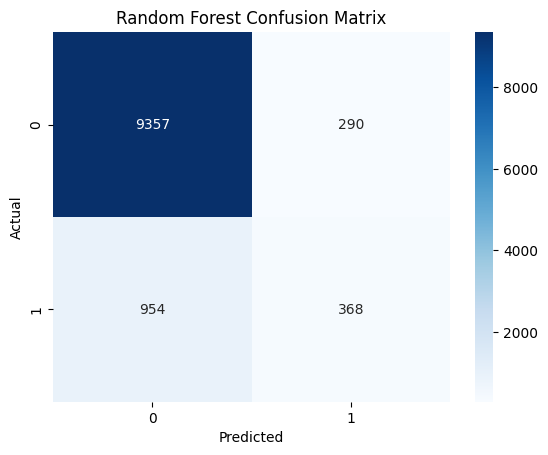

In [ ]:
cm = confusion_matrix(y_test, rf_pred_original)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Interpretation: The Random Forest model correctly classified 9,357 customers who did not subscribe and 368 customers who did subscribe. However, it incorrectly predicted 290 customers would subscribe when they did not and missed 954 customers who actually subscribed. These results suggest that the model is very effective at identifying non-subscribers but has more difficulty identifying all potential subscribers.